In [219]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


In [3]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [4]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [8]:

sql = f"""
select * from tmp1.stckln_amz_mattress_ms_trend 
"""

df = bqclient.query(sql).to_dataframe()

In [20]:
print(df)

       RetailerSku         category    subcategory profile   size  \
0       B07KNGW8BX  Spring Mattress        Bonnell       8   Full   
1       B07KNGW8BX  Spring Mattress        Bonnell       8   Full   
2       B09JP9N6GL  Spring Mattress        Bonnell      12  Queen   
3       B0D8Q1VNN8  Spring Mattress        Bonnell       6   Twin   
4       B0BBHF5321  Spring Mattress        Bonnell       8   Full   
...            ...              ...            ...     ...    ...   
518298  B0DLGTYD9Q  Spring Mattress  Pocket Spring      10   Twin   
518299  B0DLGTYD9Q  Spring Mattress  Pocket Spring      10   Twin   
518300  B0DLGGCVSH  Spring Mattress  Pocket Spring      12   Twin   
518301  B0DLGGCVSH  Spring Mattress  Pocket Spring      12   Twin   
518302  B0C6B7QP7L             null           null    null  Queen   

       bsr_ctgry_label Brand_raw Brand_adj  \
0       01. Mattresses   SOMETTE   SOMETTE   
1       01. Mattresses   SOMETTE   SOMETTE   
2       01. Mattresses     NUTAN 

In [12]:
df['RetailerSku'].nunique()

23253

In [14]:
df['Brand_raw'].nunique()

884

In [16]:
# WeekEnding이 object 타입이라면 datetime으로 변환
df['WeekEnding'] = pd.to_datetime(df['WeekEnding'], errors='coerce')

# 연도 컬럼 추가
df['year'] = df['WeekEnding'].dt.year
df['year'].isna().sum()

0

In [22]:
df.to_csv("data_0717.csv", index=False)

### 데이터 탐색

### 2025년 Amazon Mattress 카테고리 Data 분석

In [221]:
df = pd.read_csv('data_0717.csv')

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518303 entries, 0 to 518302
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   RetailerSku                        518303 non-null  object 
 1   category                           518302 non-null  object 
 2   subcategory                        518302 non-null  object 
 3   profile                            441897 non-null  float64
 4   size                               442175 non-null  object 
 5   bsr_ctgry_label                    518303 non-null  object 
 6   Brand_raw                          518303 non-null  object 
 7   Brand_adj                          518303 non-null  object 
 8   Title                              518303 non-null  object 
 9   WeekEnding                         518303 non-null  object 
 10  RetailSales                        518303 non-null  float64
 11  UnitsSold                          5183

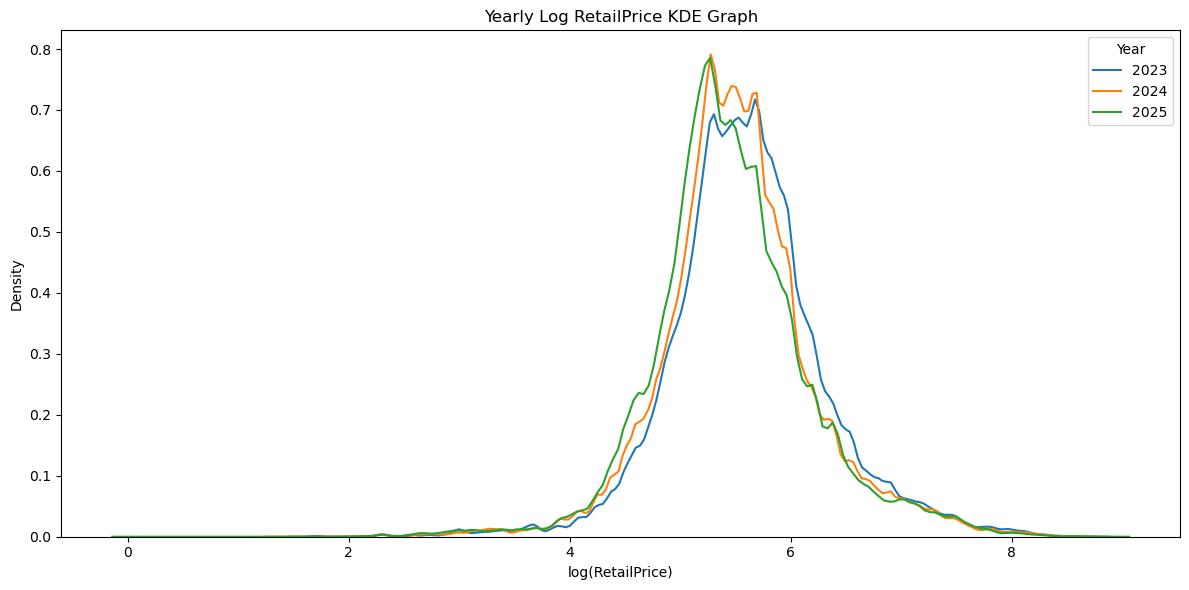

In [36]:
plt.figure(figsize=(12, 6))

# 년도별 반복
for year, group in df.groupby('year'):
    prices = group['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    sns.kdeplot(log_prices, label=year, bw_adjust=0.7)


plt.xlabel('log(RetailPrice)')
plt.ylabel('Density')
plt.title('Yearly Log RetailPrice KDE Graph')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

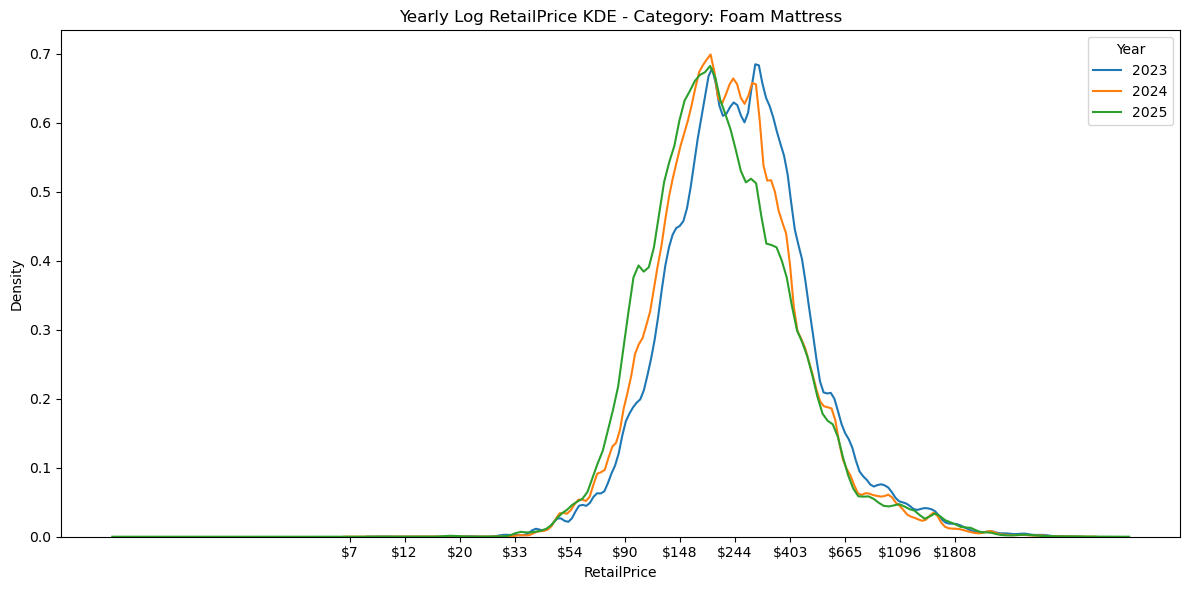

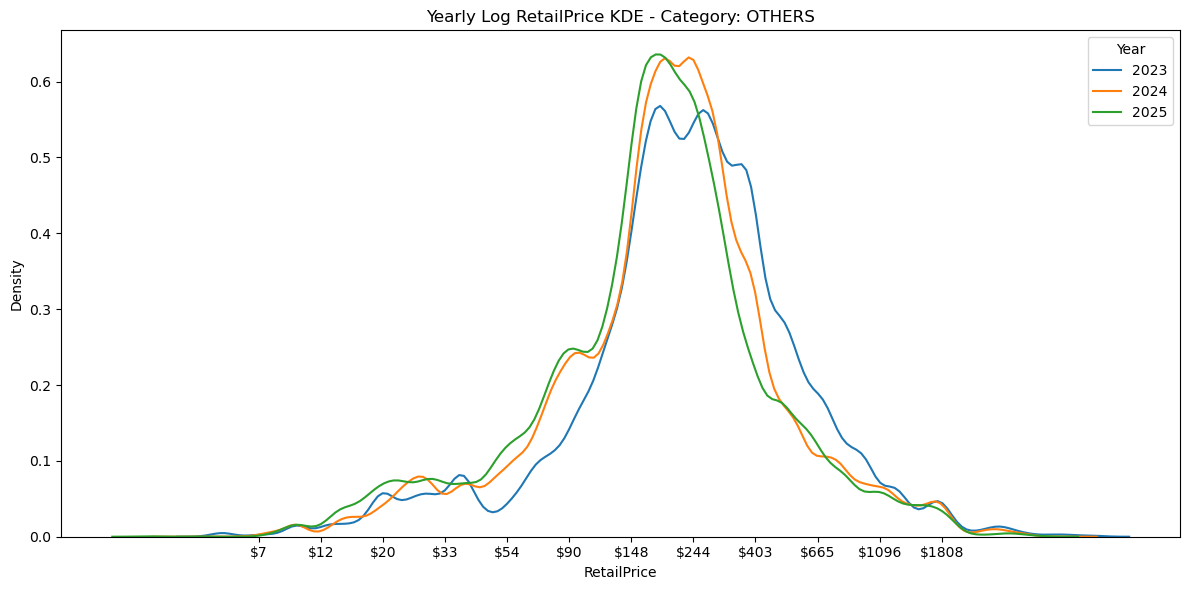

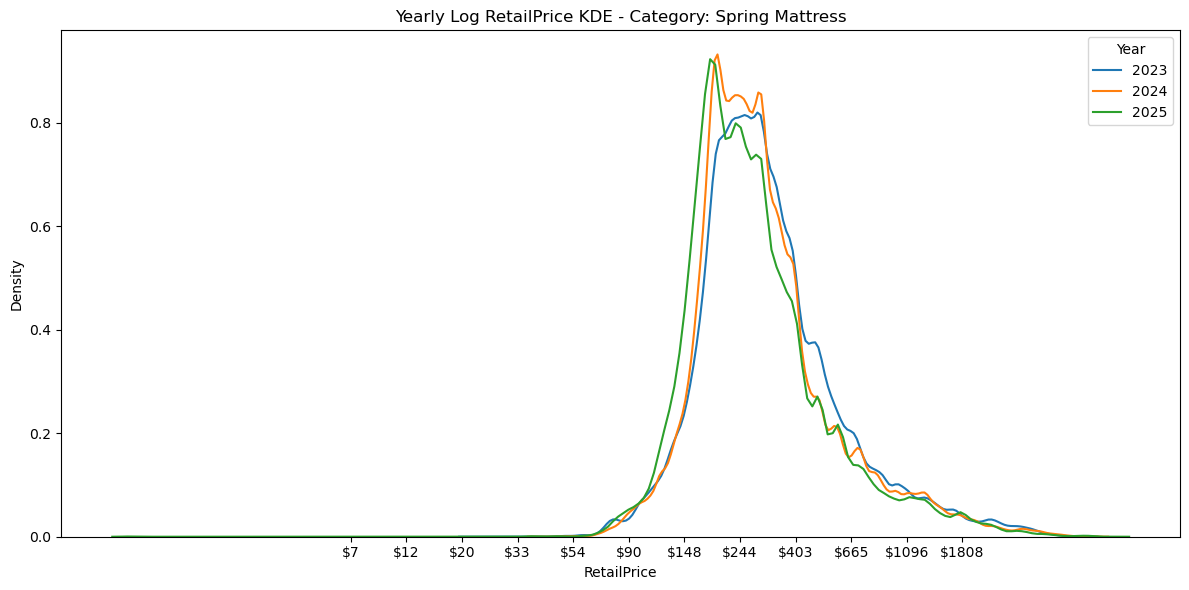

In [42]:
# 카테고리별 반복
for category, cat_group in df.groupby('category'):
    plt.figure(figsize=(12, 6))

    # 연도별 반복
    for year, group in cat_group.groupby('year'):
        prices = group['RetailPrice'].dropna()
        prices = prices[prices > 0]
        log_prices = np.log(prices)
        sns.kdeplot(log_prices, label=year, bw_adjust=0.7)

    # 로그축 x → 실제 가격으로 표시
    xticks = np.arange(2, 8, 0.5)  # log(가격) 범위 설정 (ex: e^2 ≈ $7, e^8 ≈ $2980)
    xtick_labels = [f"${int(np.exp(x))}" for x in xticks]

    plt.xticks(xticks, xtick_labels)
    plt.xlabel('RetailPrice')
    plt.ylabel('Density')
    plt.title(f'Yearly Log RetailPrice KDE - Category: {category}')
    plt.legend(title='Year')
    plt.tight_layout()
    plt.show()

In [44]:
df.groupby(['category', 'subcategory'])['Brand_raw'].nunique().reset_index(name='brand_count')

,category,subcategory,brand_count
0,Foam Mattress,Cooling/Gel,294
1,Foam Mattress,Non-Cooling,282
2,OTHERS,OTHERS,681
3,Spring Mattress,Bonnell,69
4,Spring Mattress,Continuous Coil,1
5,Spring Mattress,Cooling/Gel,3
6,Spring Mattress,Pocket Spring,371


In [46]:
df.groupby('Brand_raw')['RetailSales'].sum().reset_index().rename(columns={'RetailSales': 'total_sales'}).sort_values('total_sales', ascending=False)

,Brand_raw,total_sales
870,ZINUS,7.126604e+08
549,NOVILLA,2.286109e+08
247,FDW,1.945317e+08
529,NECTAR,1.773024e+08
507,MOLBLLY,1.770564e+08
...,...,...
13,AKOZON,1.665000e+01
246,FDIT,1.567000e+01
676,SHOWERORO,1.427000e+01
326,HOMFANSEEC,9.820000e+00


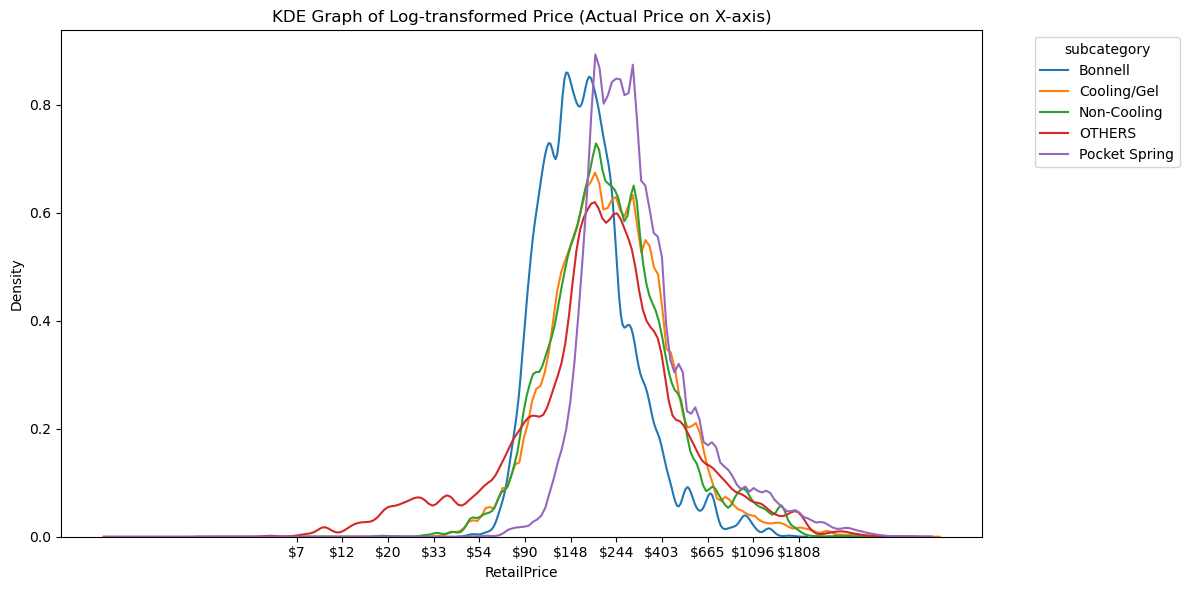

In [50]:

# 1. Continuous Coil → Bonnell로 통합
df['subcategory'] = df['subcategory'].replace('Continuous Coil', 'Bonnell')

# 2. KDE 그리기
plt.figure(figsize=(12, 6))

for subcat, group in df.groupby('subcategory'):
    prices = group['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    if len(log_prices) > 1:  # 2개 이상일 때만 KDE
        sns.kdeplot(log_prices, label=subcat, bw_adjust=0.7)

# 3. X축을 실제 가격 단위로 설정
xticks = np.arange(2, 8, 0.5)  # 로그 스케일 (e^2 ≈ $7 ~ e^8 ≈ $2980)
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]
plt.xticks(xticks, xtick_labels)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('KDE Graph of Log-transformed Price (Actual Price on X-axis)')
plt.legend(title='subcategory', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

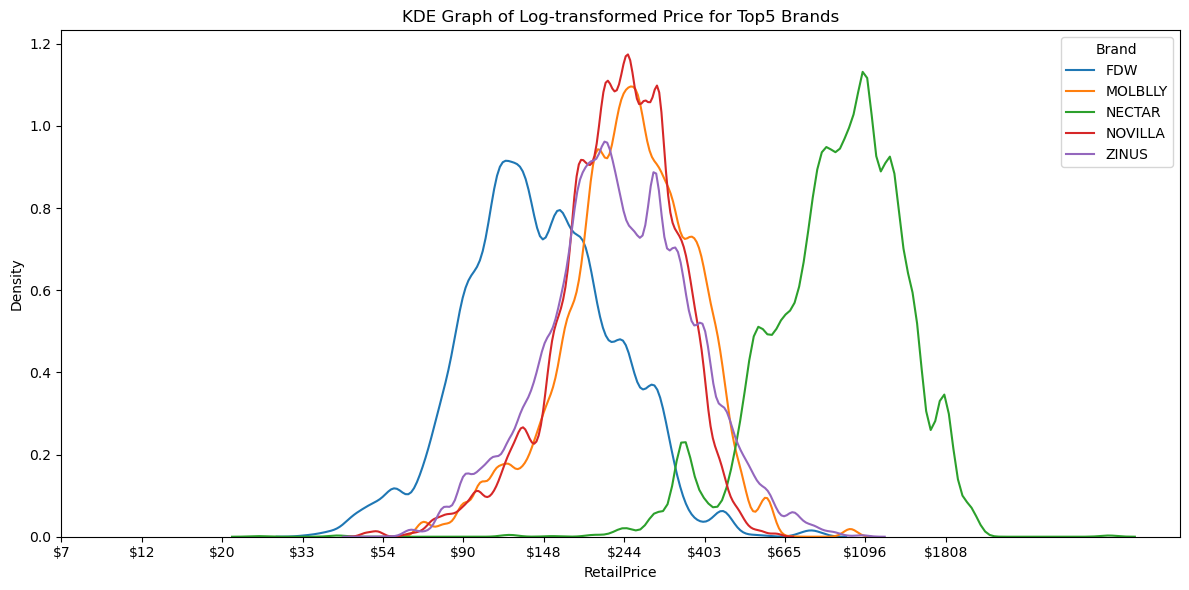

In [54]:
# 1. 브랜드별 매출 합계 집계
top5_brands = (
    df.groupby('Brand_raw')['RetailSales']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

# 2. Top 5 브랜드의 데이터만 선택
df_top5 = df[df['Brand_raw'].isin(top5_brands)]

# 3. 브랜드별로 로그변환된 가격 KDE plot
plt.figure(figsize=(12, 6))

for brand, group in df_top5.groupby('Brand_raw'):
    prices = group['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    if len(log_prices) > 1:
        sns.kdeplot(log_prices, label=brand, bw_adjust=0.7)


# 4. X축을 실제 가격 단위로 표시
xticks = np.arange(2, 8, 0.5)  # 로그값 범위 (e^2 ≈ $7 ~ e^8 ≈ $2980)
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]
plt.xticks(xticks, xtick_labels)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('KDE Graph of Log-transformed Price for Top5 Brands')
plt.legend(title='Brand')
plt.tight_layout()
plt.show()

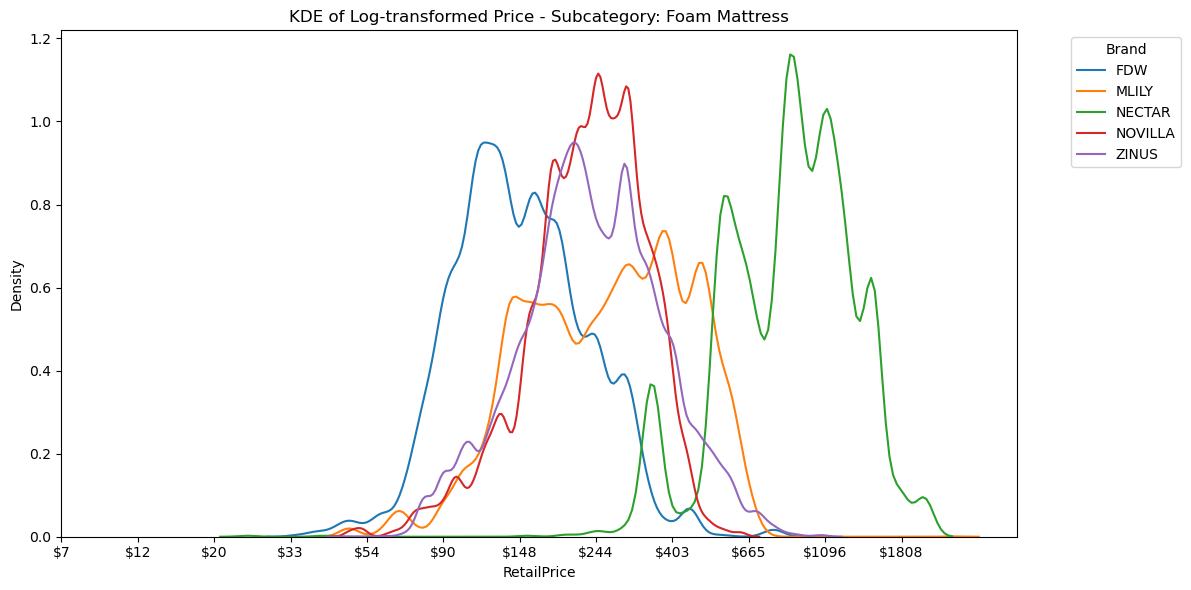

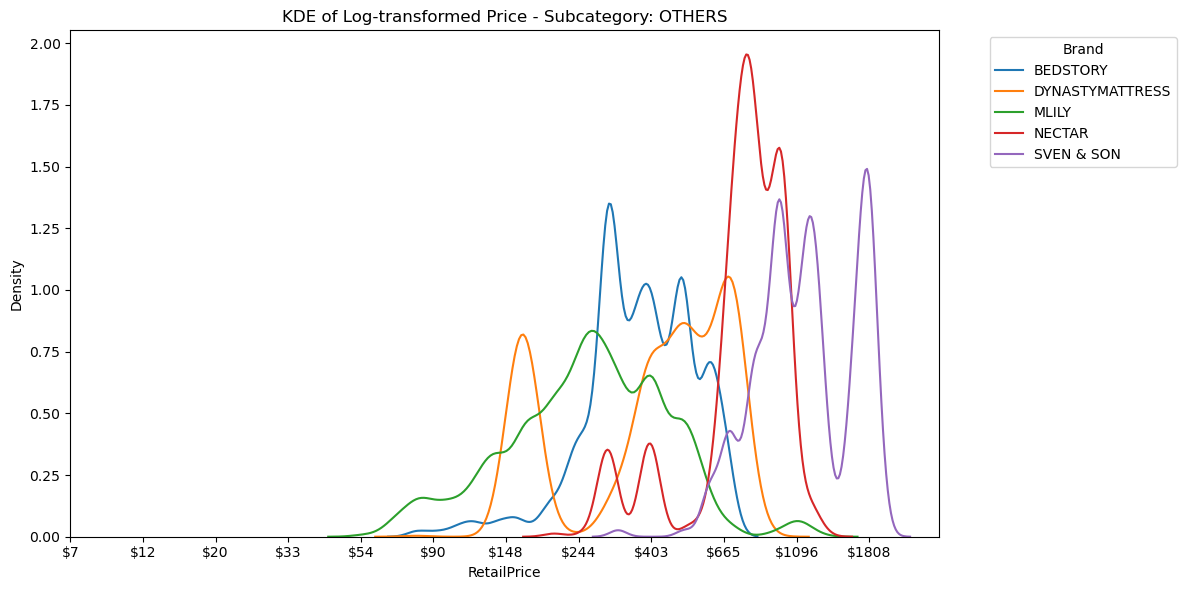

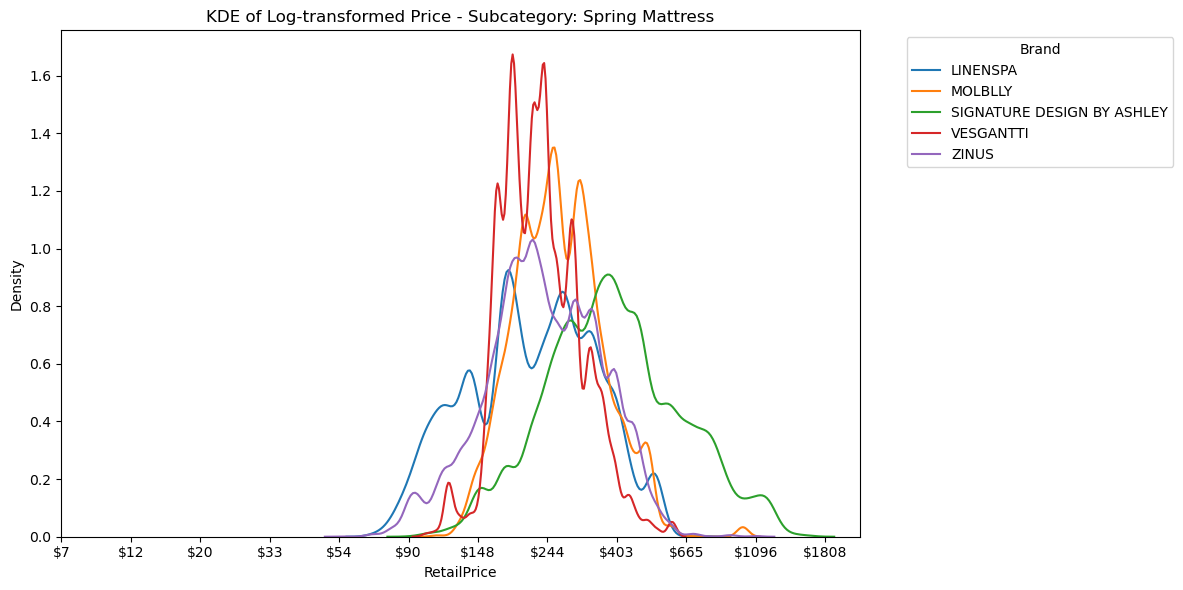

In [168]:
# 1. Subcategory별 Top 10 브랜드 추출
top10_brands_by_subcat = (
    df.groupby(['category', 'Brand_raw'])['RetailSales']
      .sum()
      .reset_index()
      .sort_values(['category', 'RetailSales'], ascending=[True, False])
      .groupby('category')
      .head(5)
)

# 2. Top 브랜드 데이터 필터링
df_top = df.merge(top10_brands_by_subcat[['category', 'Brand_raw']], 
                  on=['category', 'Brand_raw'], how='inner')

# 3. Subcategory별로 개별 KDE plot 생성
for subcat, group_subcat in df_top.groupby('category'):
    plt.figure(figsize=(12, 6))
    
    for brand, group in group_subcat.groupby('Brand_raw'):
        prices = group['RetailPrice'].dropna()
        prices = prices[prices > 0]
        log_prices = np.log(prices)
        if len(log_prices) > 1:
            sns.kdeplot(log_prices, label=brand, bw_adjust=0.7)
    
    # X축: 실제 가격 단위로 변환
    xticks = np.arange(2, 8, 0.5)
    xtick_labels = [f"${int(np.exp(x))}" for x in xticks]
    plt.xticks(xticks, xtick_labels)
    
    plt.xlabel('RetailPrice')
    plt.ylabel('Density')
    plt.title(f'KDE of Log-transformed Price - Subcategory: {subcat}')
    plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\3222339699.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


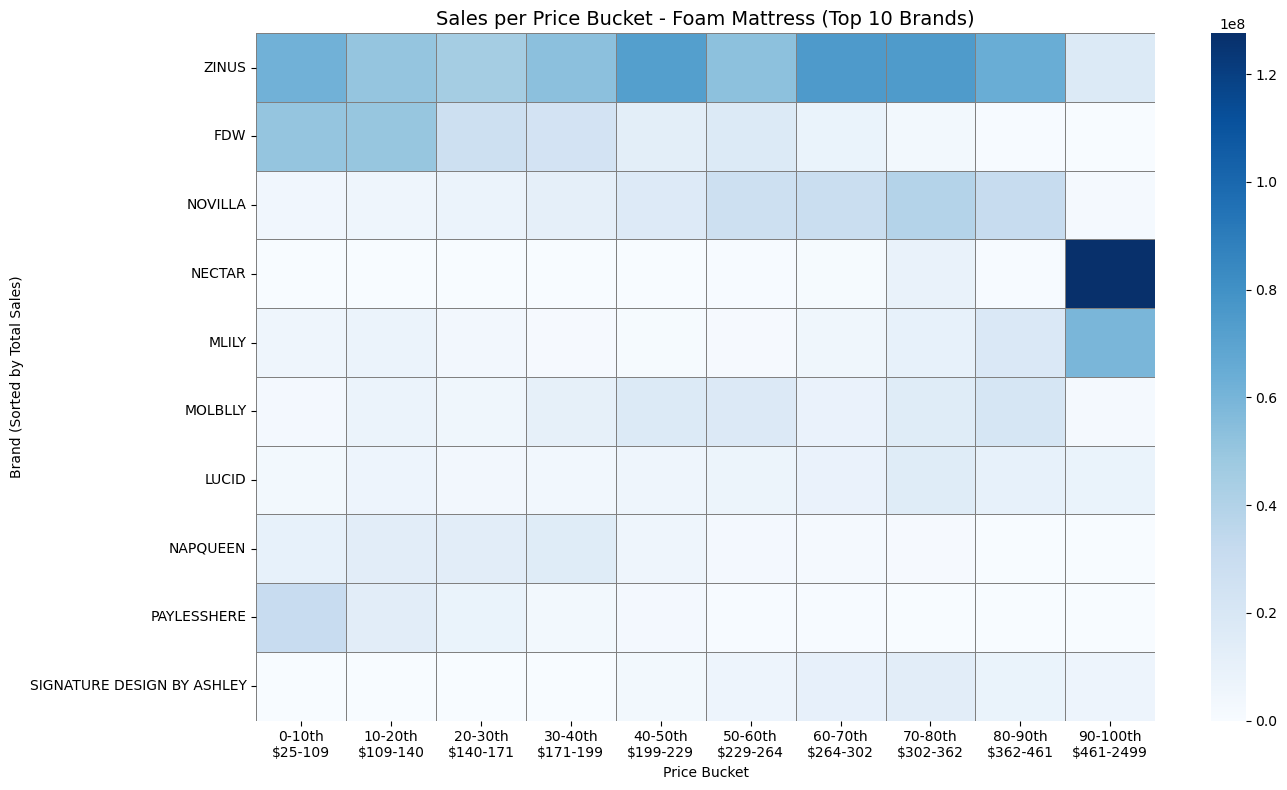

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\3222339699.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


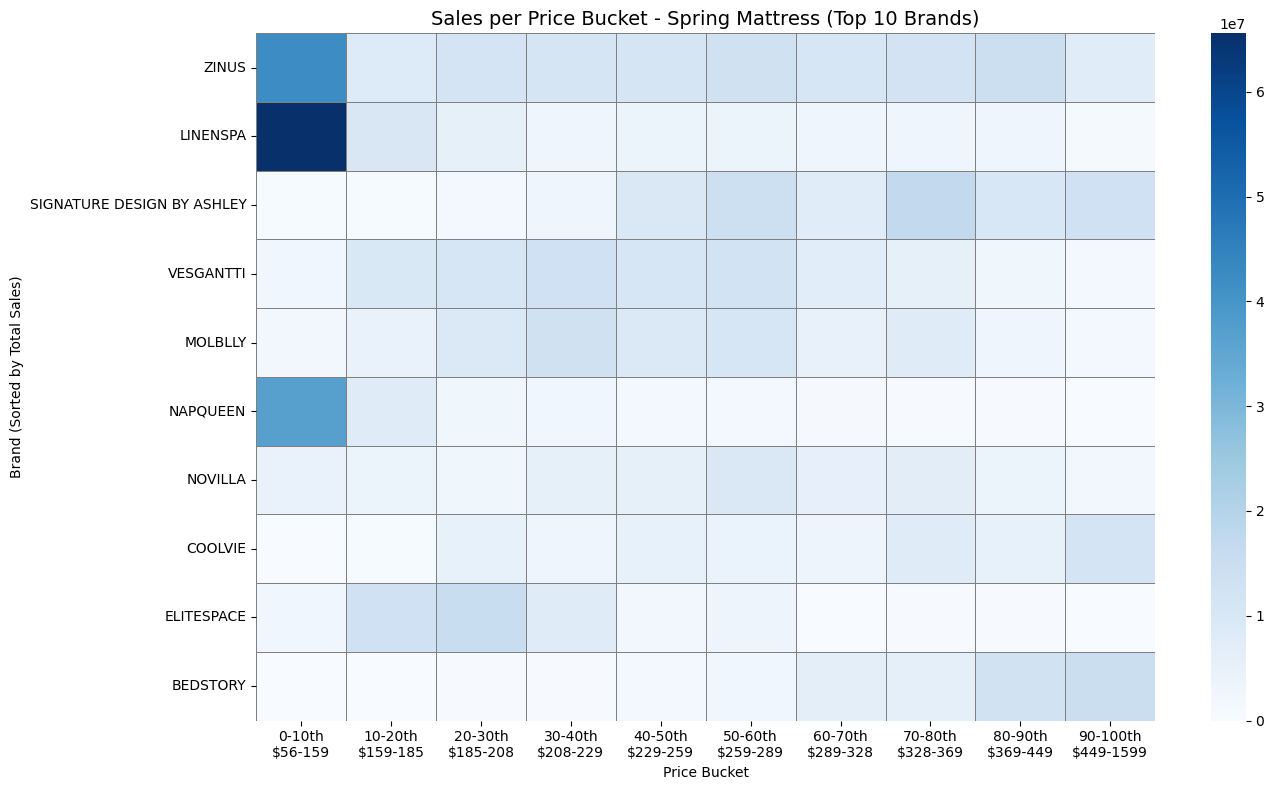

In [110]:

# "OTHERS" 카테고리 제외
df_filtered = df[df['category'] != 'OTHERS']

# Category별 반복
for category, df_cat in df_filtered.groupby('category'):

    # 1. 해당 카테고리 내 Top 10 브랜드 추출
    top10_brands = (
        df_cat.groupby('Brand_raw')['RetailSales']
              .sum()
              .sort_values(ascending=False)
              .head(10)
              .index
    )

    # 2. Top 10 브랜드만 필터링
    df_top = df_cat[df_cat['Brand_raw'].isin(top10_brands)].copy()

    # 3. 가격 퍼센타일 경계 계산
    percentiles = np.arange(0, 101, 10)
    price_bins = np.percentile(df_top['RetailPrice'].dropna(), q=percentiles)

    # 4. 구간 라벨 생성
    bucket_labels = [
        f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 5. 가격 버킷 할당
    df_top['PriceBucket'] = pd.cut(
        df_top['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )

    # 6. 브랜드 x 가격버킷 매출 집계
    heatmap_data = (
        df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']
              .sum()
              .unstack(fill_value=0)
    )

    # ✅ 7. 브랜드 순서를 총 매출 기준 내림차순으로 정렬
    brand_order = heatmap_data.sum(axis=1).sort_values(ascending=False).index
    heatmap_data = heatmap_data.loc[brand_order]

    # 8. 히트맵 시각화
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )

    plt.title(f"Sales per Price Bucket - {category} (Top 10 Brands)", fontsize=14)
    plt.xlabel("Price Bucket")
    plt.ylabel("Brand (Sorted by Total Sales)")
    plt.tight_layout()
    plt.show()

### Sales per Price Bucket by Year for Top 10 Brands

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2550043499.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


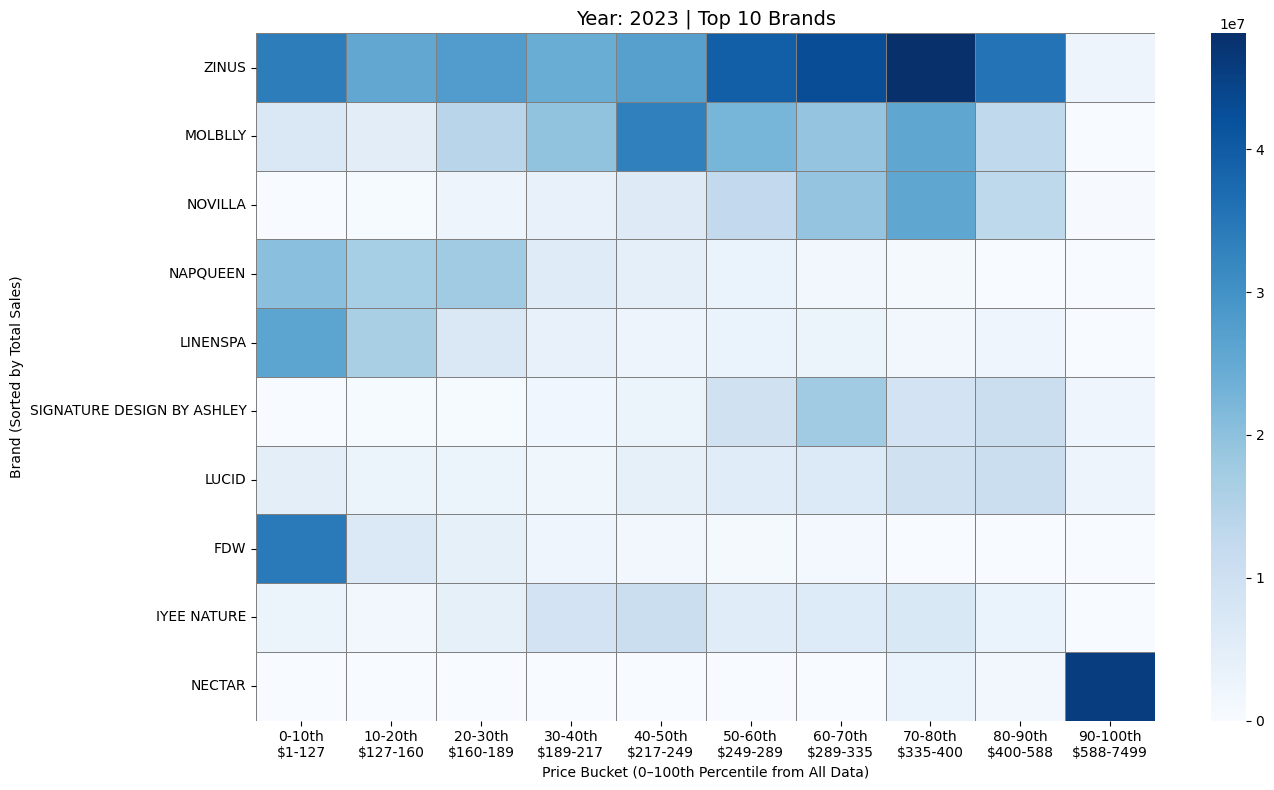

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2550043499.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


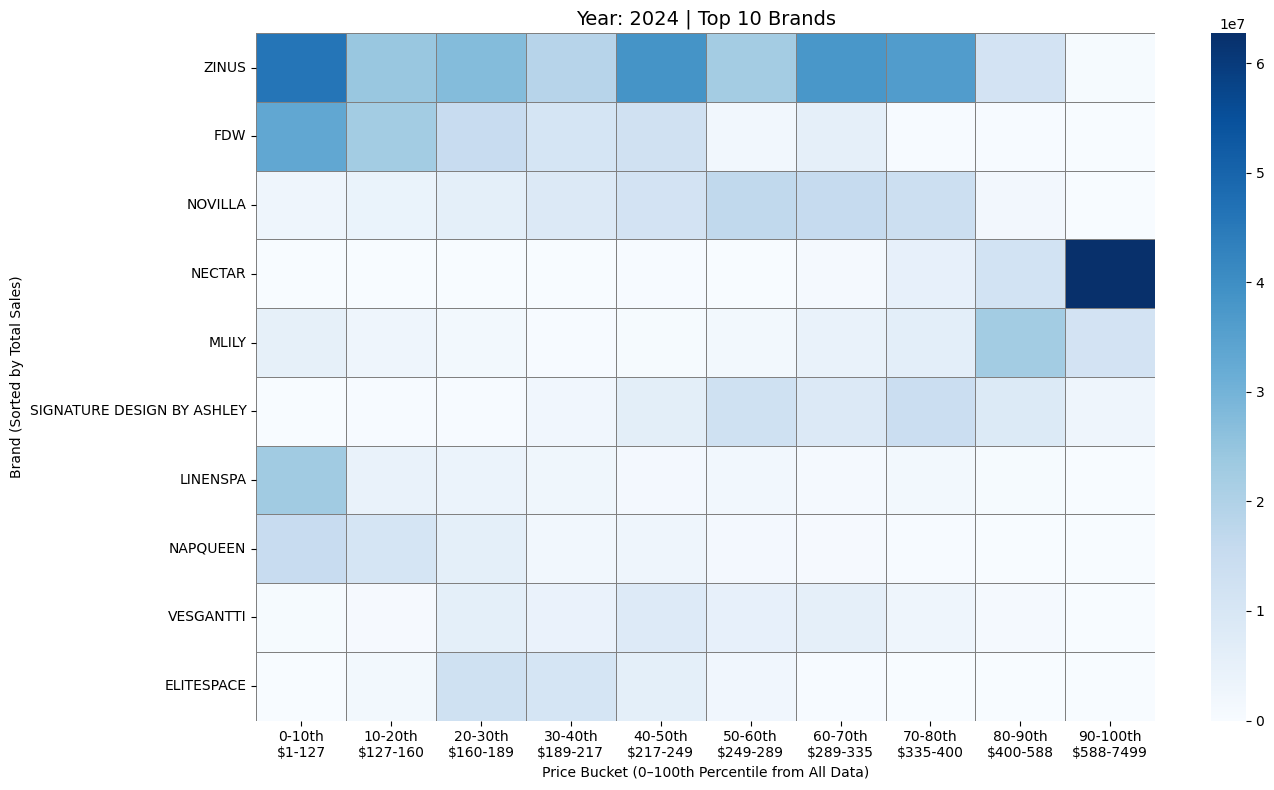

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2550043499.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


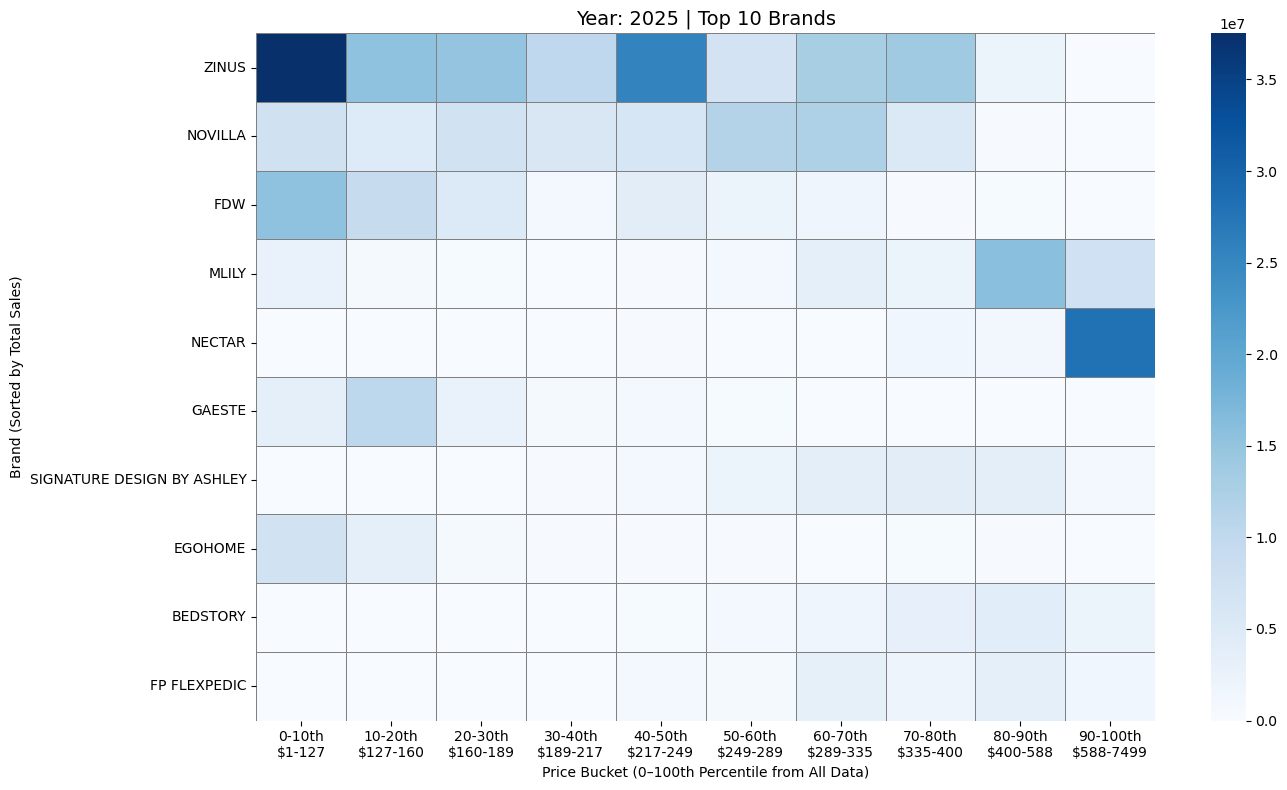

In [116]:

# 0. OTHERS 제외
df_filtered = df[df['category'] != 'OTHERS'].copy()

# ✅ 1. 전체 데이터 기준으로 가격 퍼센타일 구간 계산
percentiles = np.arange(0, 101, 10)
base_prices = df_filtered['RetailPrice'].dropna()
price_bins = np.percentile(base_prices, q=percentiles)

# 2. 구간 라벨 생성 (10개 구간)
bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# ✅ 3. 연도별 반복
for year, df_year in df_filtered.groupby('year'):

    # Top 10 브랜드 추출
    top10_brands = (
        df_year.groupby('Brand_raw')['RetailSales']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .index
    )

    df_top = df_year[df_year['Brand_raw'].isin(top10_brands)].copy()

    if df_top.empty or df_top['RetailPrice'].nunique() < 5:
        continue

    # 가격 버킷 할당 (전체 공통 기준 사용)
    df_top['PriceBucket'] = pd.cut(
        df_top['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )

    # PriceBucket 없는 값 제거
    df_top = df_top.dropna(subset=['PriceBucket'])

    # 브랜드 x 가격 버킷 매출 합계
    heatmap_data = (
        df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']
              .sum()
              .unstack(fill_value=0)
    )

    # 브랜드 정렬 (총 매출 기준)
    brand_order = heatmap_data.sum(axis=1).sort_values(ascending=False).index
    heatmap_data = heatmap_data.loc[brand_order]

    # ✅ 히트맵 시각화
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )

    plt.title(f"Year: {year} | Top 10 Brands", fontsize=14)
    plt.xlabel("Price Bucket (0–100th Percentile from All Data)")
    plt.ylabel("Brand (Sorted by Total Sales)")
    plt.tight_layout()
    plt.show()

### Sales per Price Bucket by Category and Year for Top 10 Brands

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1993381174.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


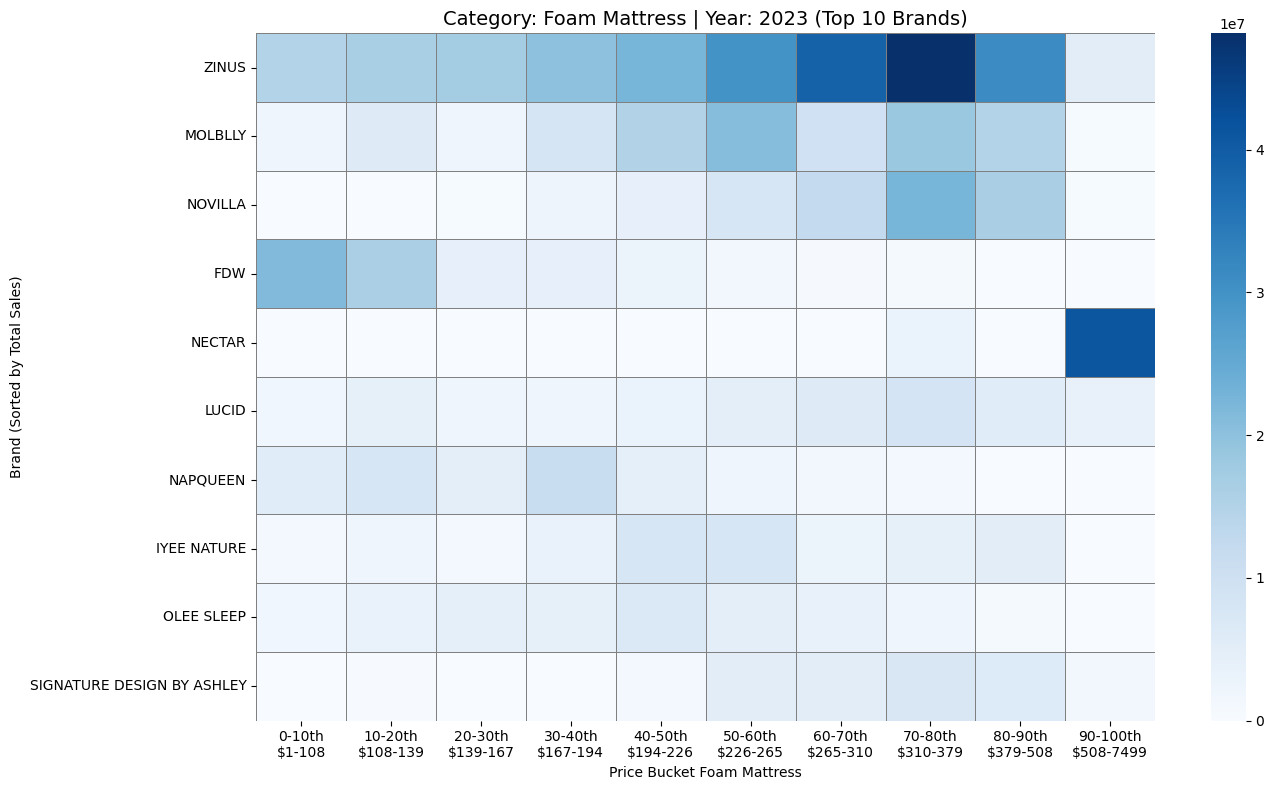

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1993381174.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


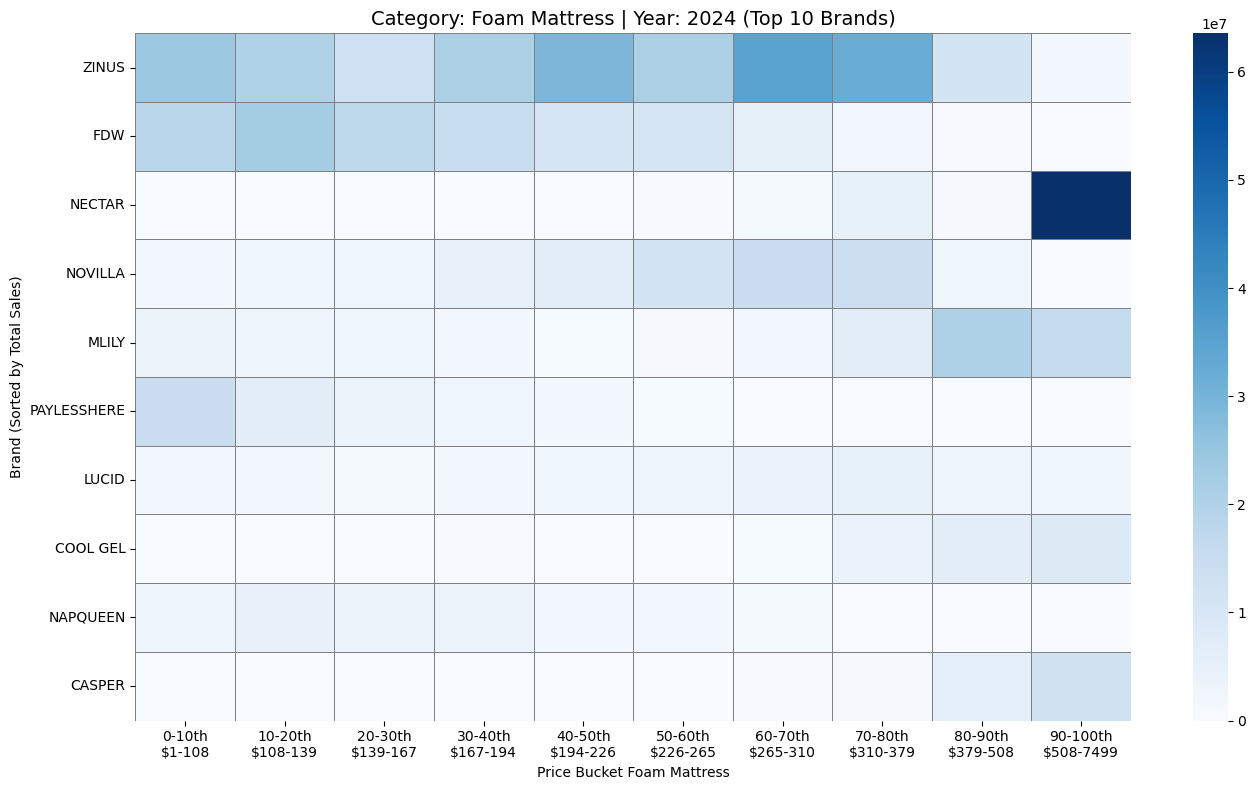

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1993381174.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


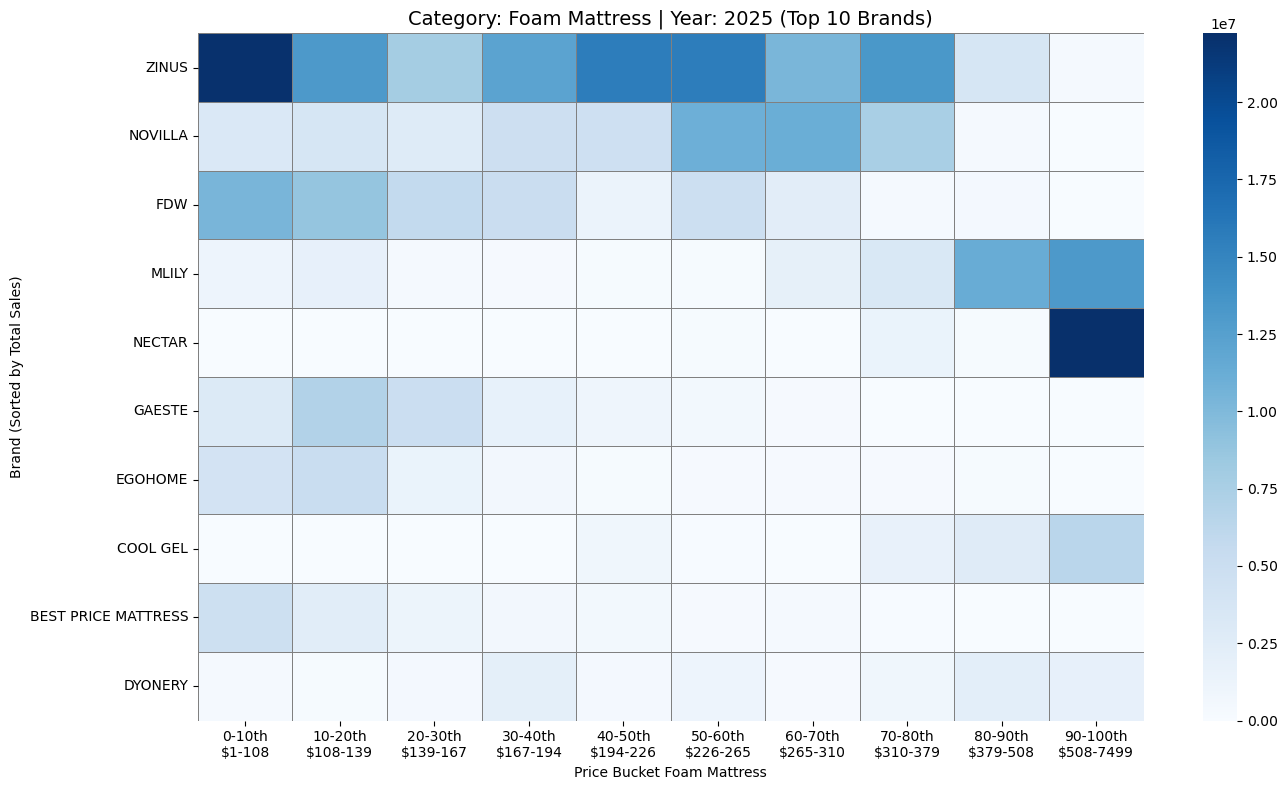

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1993381174.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


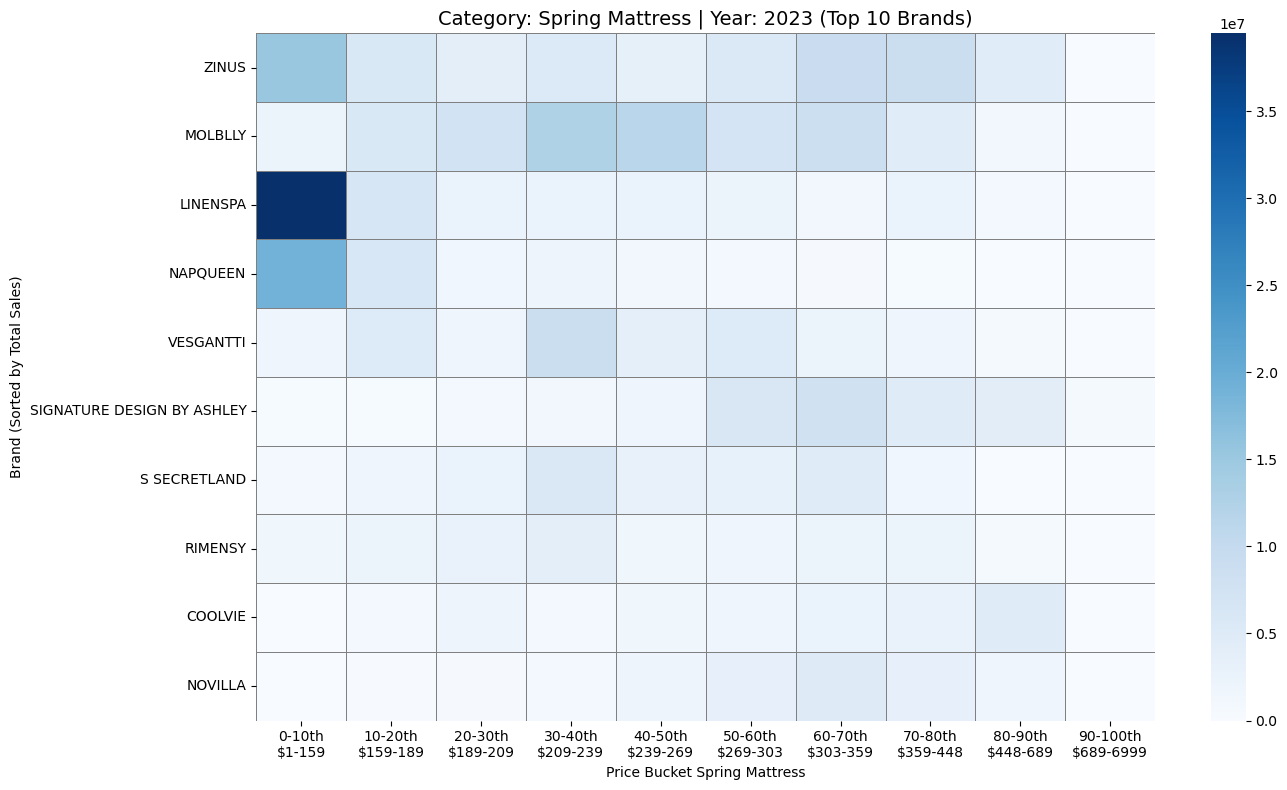

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1993381174.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


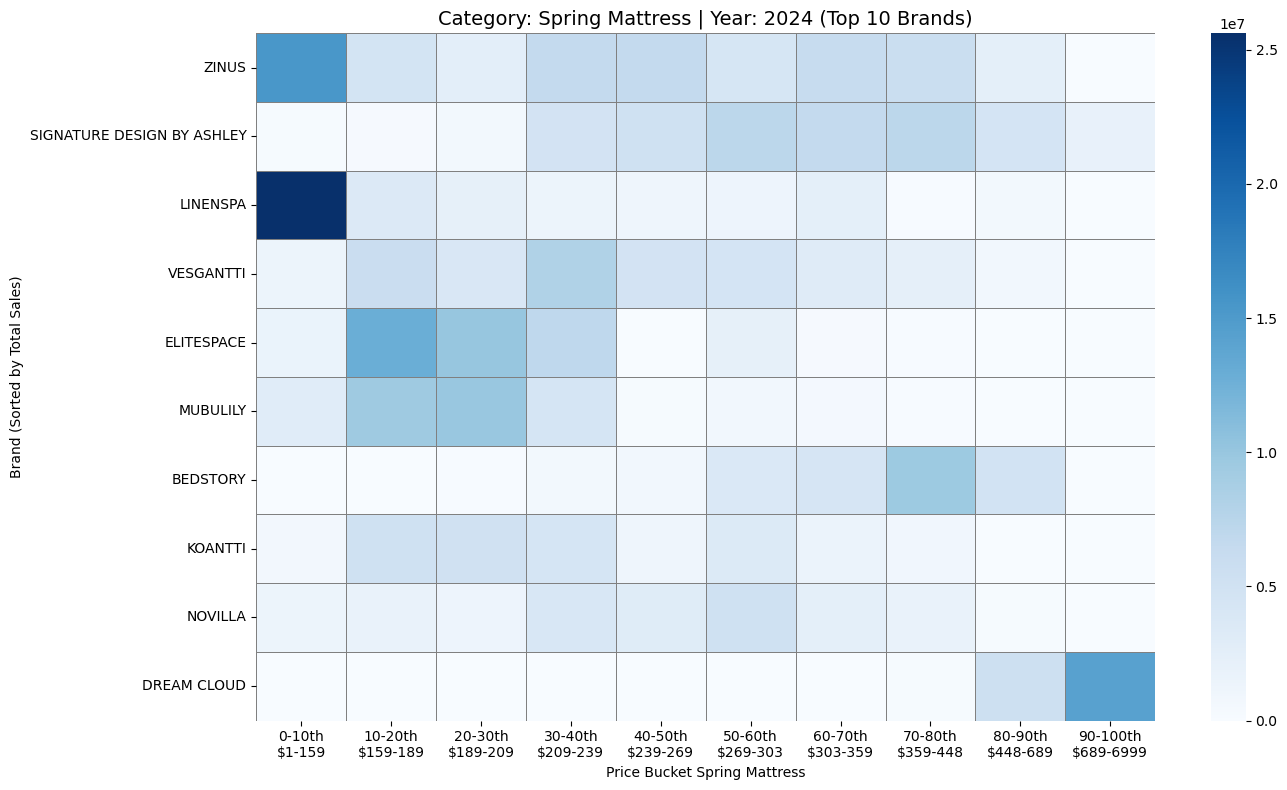

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1993381174.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']


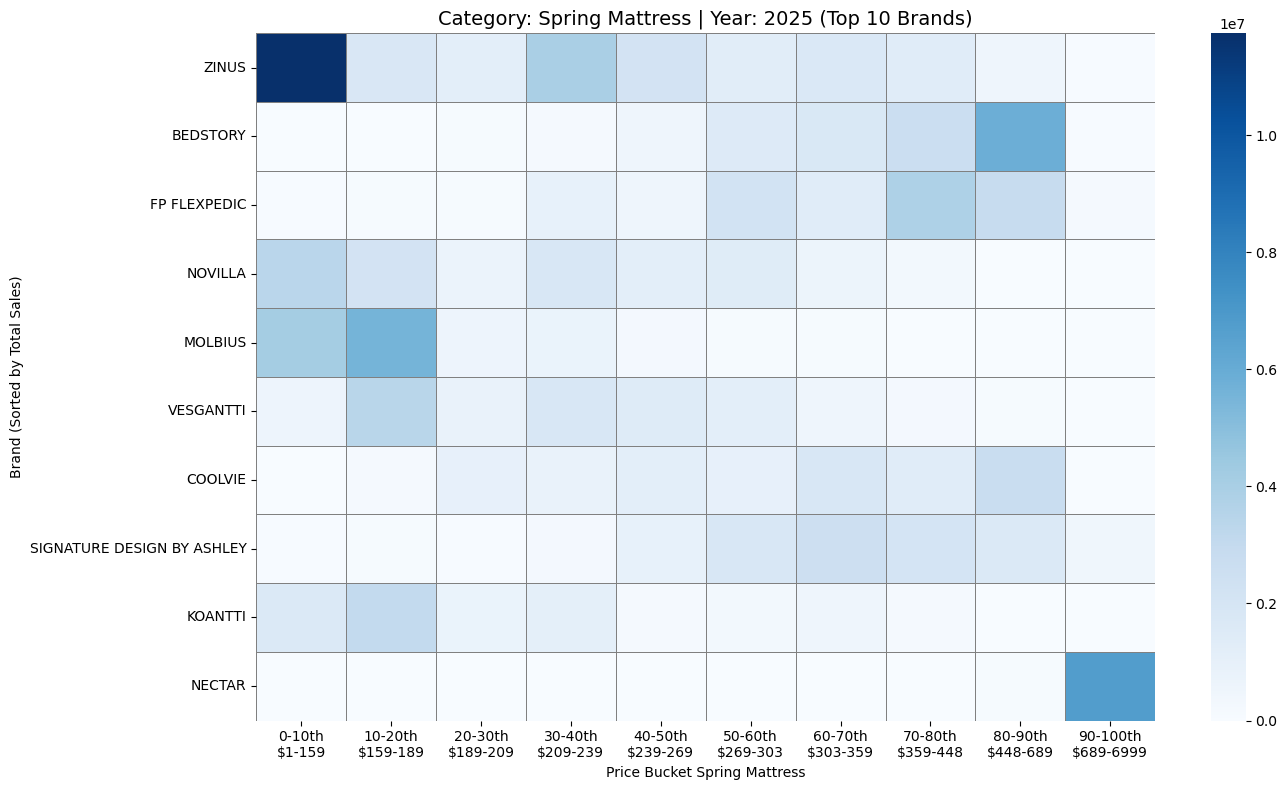

In [118]:
# 0. OTHERS 카테고리 제외
df_filtered = df[df['category'] != 'OTHERS'].copy()

# ✅ 1. Foam Mattress / Spring Mattress용 가격 퍼센타일 기준 계산
price_bin_dict = {}
percentiles = np.arange(0, 101, 10)

for base_cat in ['Foam Mattress', 'Spring Mattress']:
    #base_df = df_filtered[(df_filtered['category'] == base_cat) & (df_filtered['year'] == 2025)]
    base_df = df_filtered[(df_filtered['category'] == base_cat)]
    base_prices = base_df['RetailPrice'].dropna()
    if len(base_prices) >= 10:
        price_bins = np.percentile(base_prices, q=percentiles)
        bucket_labels = [
            f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
            for i in range(len(price_bins) - 1)
        ]
        price_bin_dict[base_cat] = {'bins': price_bins, 'labels': bucket_labels}
    else:
        print(f"⚠️ Not enough data for {base_cat} in 2025 to compute price bins.")

# ✅ 2. Category → Year 순서로 반복
for category, df_cat in df_filtered.groupby('category'):
    # 해당 카테고리에 대응하는 가격 구간이 없으면 스킵
    if category not in price_bin_dict:
        continue

    bins = price_bin_dict[category]['bins']
    labels = price_bin_dict[category]['labels']

    for year, df_group in df_cat.groupby('year'):
        # Top 10 브랜드 추출
        top10_brands = (
            df_group.groupby('Brand_raw')['RetailSales']
                    .sum()
                    .sort_values(ascending=False)
                    .head(10)
                    .index
        )

        # 해당 브랜드 필터링
        df_top = df_group[df_group['Brand_raw'].isin(top10_brands)].copy()

        if df_top.empty or df_top['RetailPrice'].nunique() < 5:
            continue

        # 고정된 가격 구간에 따라 버킷 할당
        df_top['PriceBucket'] = pd.cut(
            df_top['RetailPrice'],
            bins=bins,
            labels=labels,
            include_lowest=True
        )

        # 브랜드 x 가격 버킷 매출 집계
        heatmap_data = (
            df_top.groupby(['Brand_raw', 'PriceBucket'])['RetailSales']
                  .sum()
                  .unstack(fill_value=0)
        )

        # 브랜드 매출 기준 정렬
        brand_order = heatmap_data.sum(axis=1).sort_values(ascending=False).index
        heatmap_data = heatmap_data.loc[brand_order]

        # 히트맵 시각화
        plt.figure(figsize=(14, 8))
        sns.heatmap(
            heatmap_data,
            cmap="Blues",
            linewidths=0.5,
            linecolor='gray'
        )

        plt.title(f"Category: {category} | Year: {year} (Top 10 Brands)", fontsize=14)
        #plt.xlabel(f"Price Bucket (Based on 2025 {category})")
        plt.xlabel(f"Price Bucket {category}")
        plt.ylabel("Brand (Sorted by Total Sales)")
        plt.tight_layout()
        plt.show()

### Y축이 가격대이고 X축이 Month일 때, Heatmap 출력하기

In [136]:

# 1. 2025년 1~6월 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()


C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1247966574.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBucket', 'yr_month'])['RetailSales']


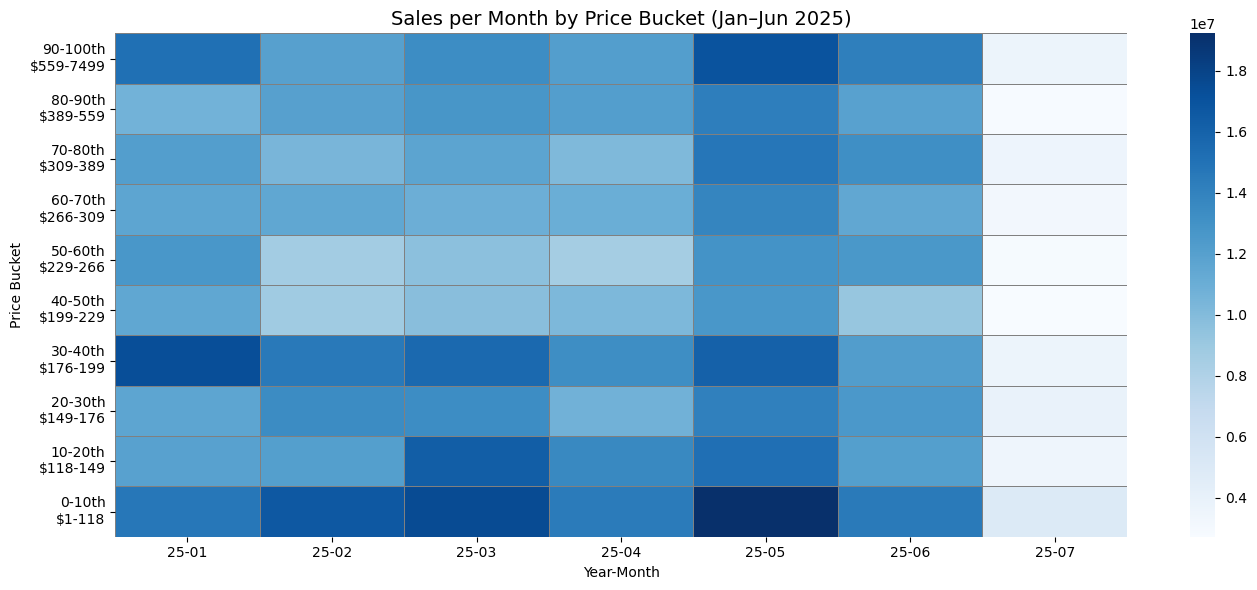

In [144]:

# 1. 2025년 1~6월 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. 가격 퍼센타일 구간 계산 (2025년 전체 기준, OTHERS 제외)
price_base = df_filtered['RetailPrice'].dropna()

percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(price_base, q=percentiles)

bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 3. 가격 버킷 할당
df_filtered['PriceBucket'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

# ✅ Y축 내림차순으로 정렬된 카테고리 순서로 재설정
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels[::-1],  # reverse order
    ordered=True
)

# 4. 가격대 × 월별 매출 합계 → 월 × 가격대 → 바꿔서 가격대 × 월
heatmap_data = (
    df_filtered.groupby(['PriceBucket', 'yr_month'])['RetailSales']
               .sum()
               .unstack(fill_value=0)
)

# 5. 히트맵 시각화
plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Sales per Month by Price Bucket (Jan–Jun 2025)", fontsize=14)
plt.xlabel("Year-Month")
plt.ylabel("Price Bucket")
plt.tight_layout()
plt.show()

### Weekly 히트맵 구하기

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2776219538.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('PriceBin')['RetailSales']


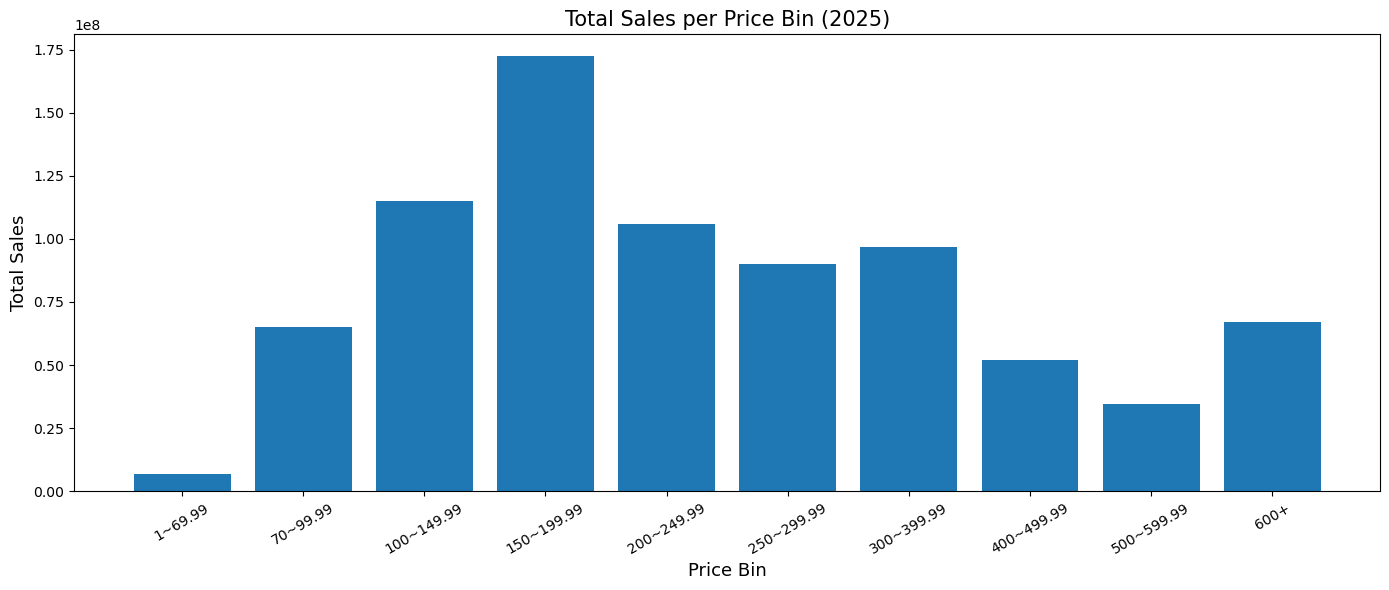

In [190]:
# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [ "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,   # 왼쪽 포함, 오른쪽 미포함 (1~50은 1 <= x < 50)
    include_lowest=True
)

# 4. Price Bin별 매출 합계 집계
sales_by_bin = (
    df_filtered.groupby('PriceBin')['RetailSales']
    .sum()
    .reindex(bin_labels)  # 빈 구간도 포함
)

# 5. 히스토그램(막대그래프) 시각화
plt.figure(figsize=(14,6))
plt.bar(sales_by_bin.index, sales_by_bin.values)
plt.xlabel("Price Bin", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)
plt.title("Total Sales per Price Bin (2025)", fontsize=15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\271820143.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']


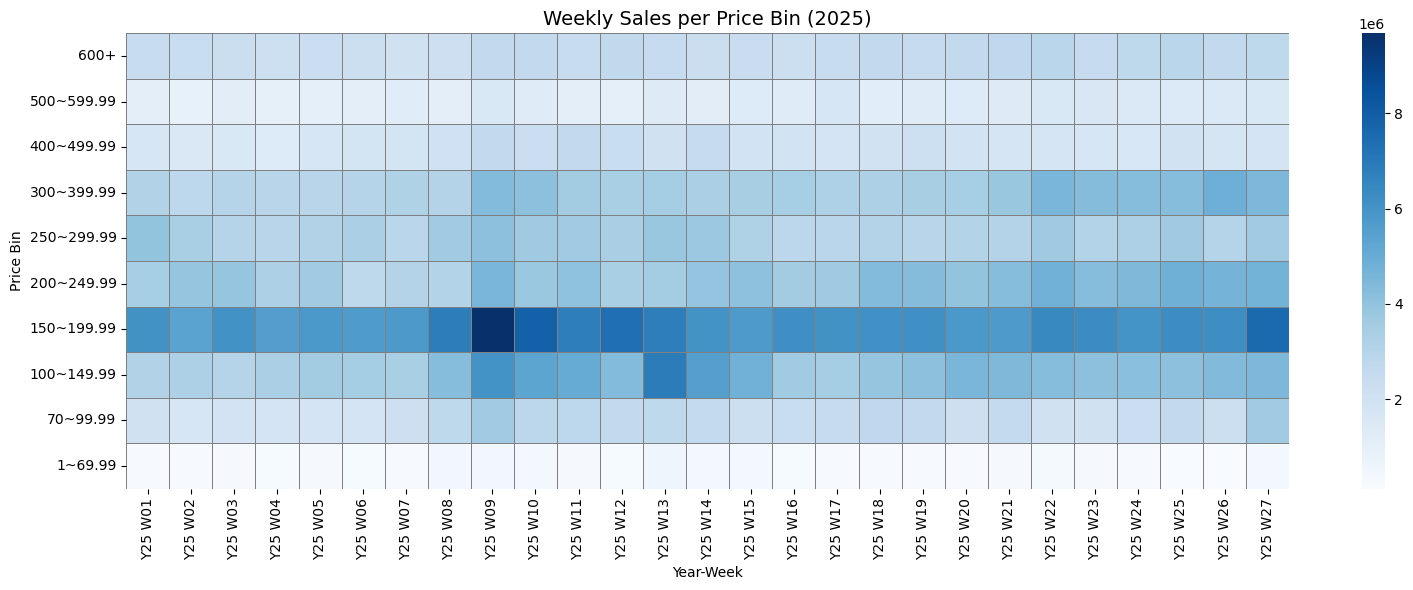

In [194]:
# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4. Y축(Price Bin), X축(yr_week) 별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']
    .sum()
    .unstack(fill_value=0)
    .reindex(index=bin_labels[::-1])  # Y축 구간 순서 고정
)

# 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bin (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bin")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


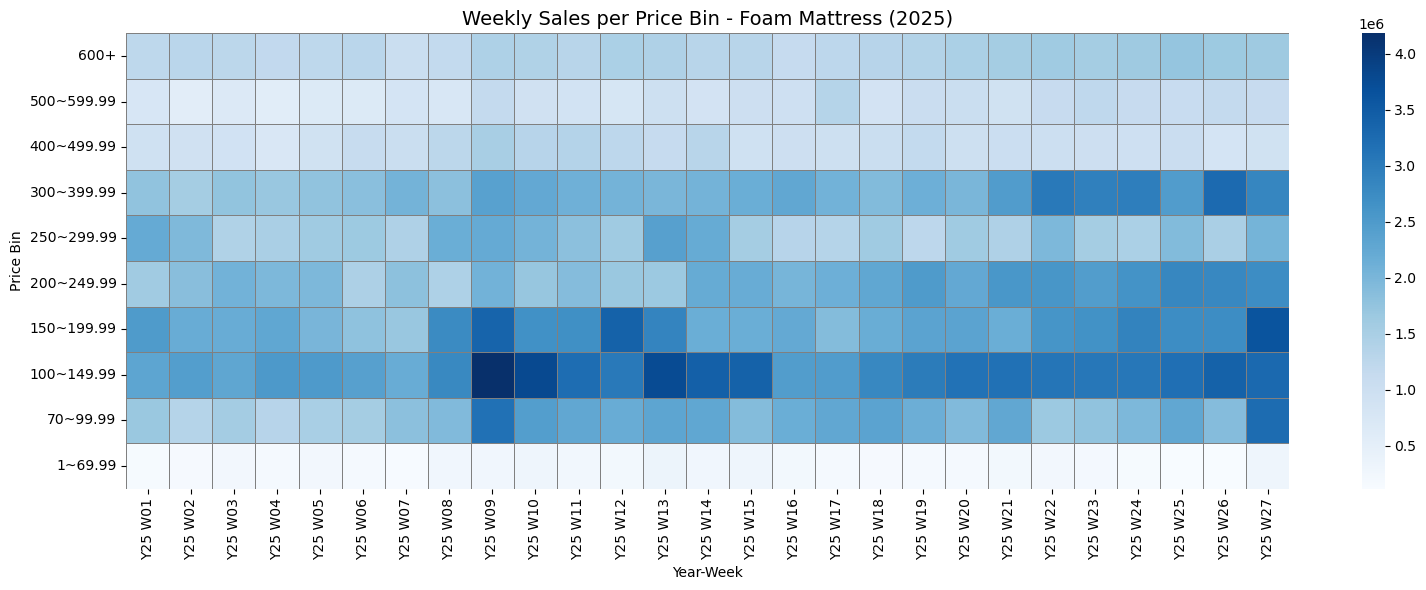

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


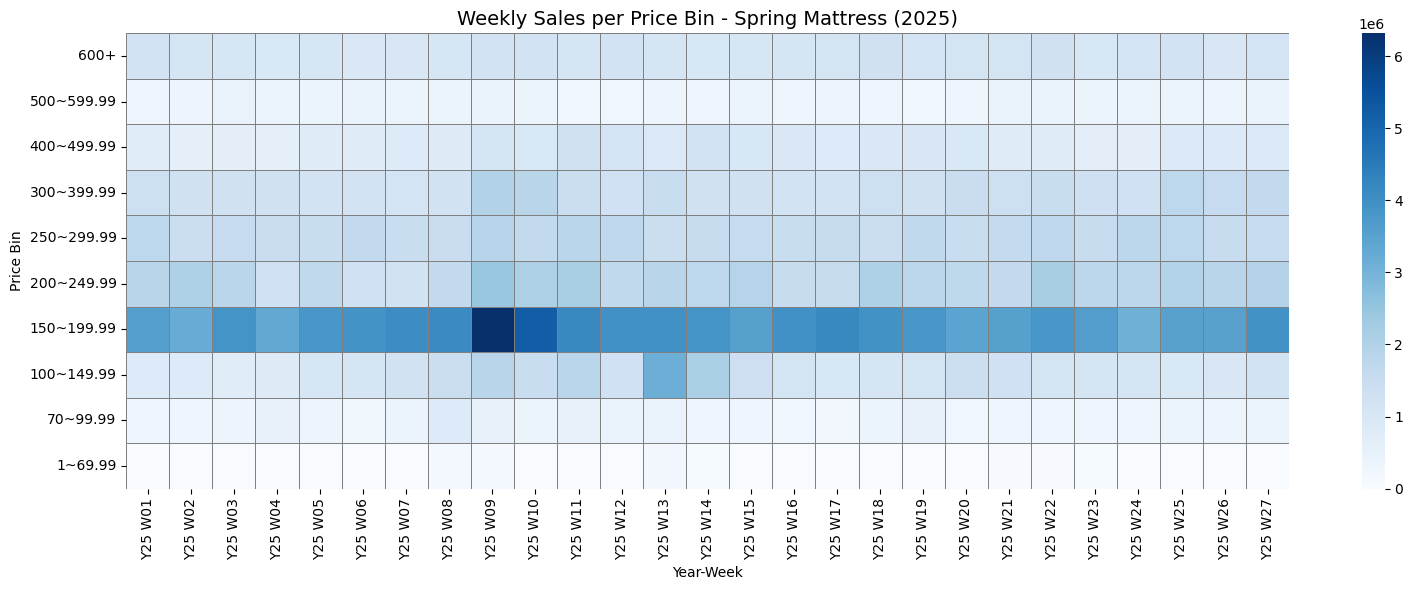

In [206]:
# Price Bin 설정
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

def draw_heatmap(df, category_name):
    df_cat = df[
        (df['category'] == category_name) & (df['year'] == 2025)
    ].copy()
    if len(df_cat) == 0:
        print(f"No data for {category_name}")
        return
    df_cat['PriceBin'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bin_labels,
        right=False,
        include_lowest=True
    )
    all_weeks = sorted(df_cat['yr_week'].unique())
    heatmap_data = (
        df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']
        .sum()
        .unstack(fill_value=0)
        .reindex(index=bin_labels[::-1], columns=all_weeks, fill_value=0)
    )
    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bin - {category_name} (2025)", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bin")
    plt.tight_layout()
    plt.show()

# Foam Mattress
draw_heatmap(df, 'Foam Mattress')

# Spring Mattress
draw_heatmap(df, 'Spring Mattress')

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2227028325.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']


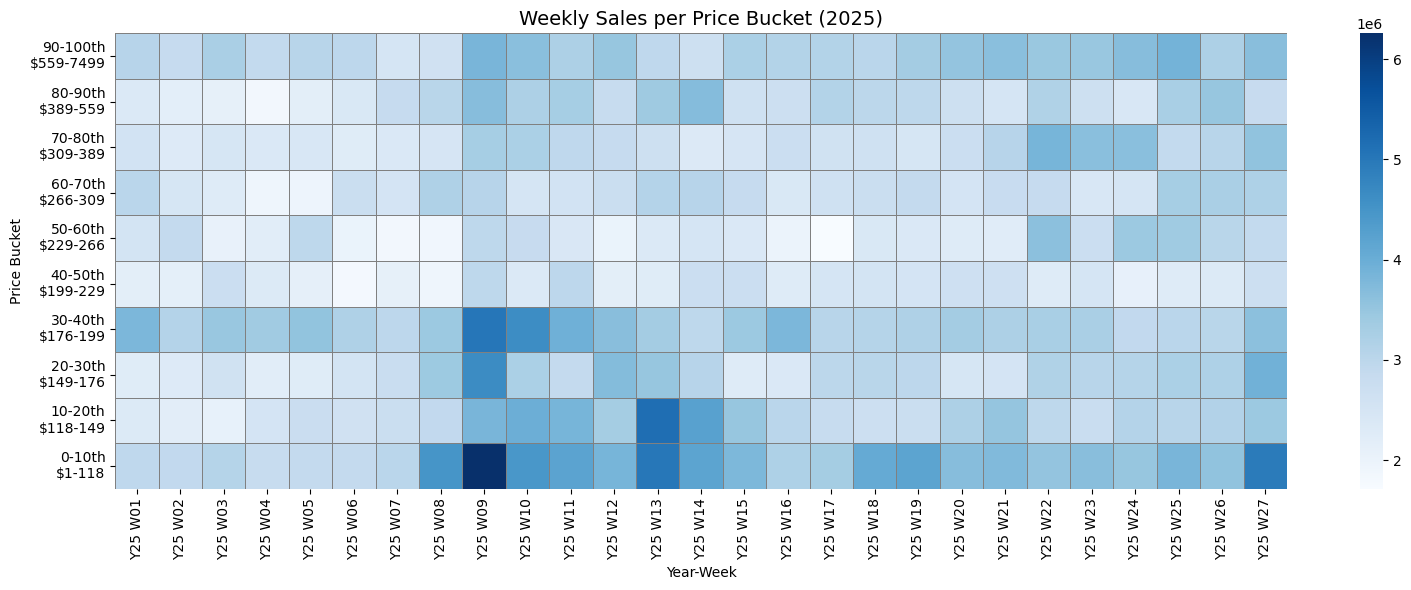

In [180]:

# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025) #&
    #(df['Brand_raw'] == 'ZINUS')
].copy()

# 2. 가격 퍼센타일 구간 계산 (2025년 전체 기준)
price_base = df_filtered['RetailPrice'].dropna()
percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(price_base, q=percentiles)

bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 3. 가격 버킷 할당
df_filtered['PriceBucket'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

# ✅ Y축 가격대 내림차순 정렬
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels[::-1],
    ordered=True
)

# ✅ 4. 가격대 × 주차별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']
               .sum()
               .unstack(fill_value=0)
)

# ✅ 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bucket (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bucket")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2022904121.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']


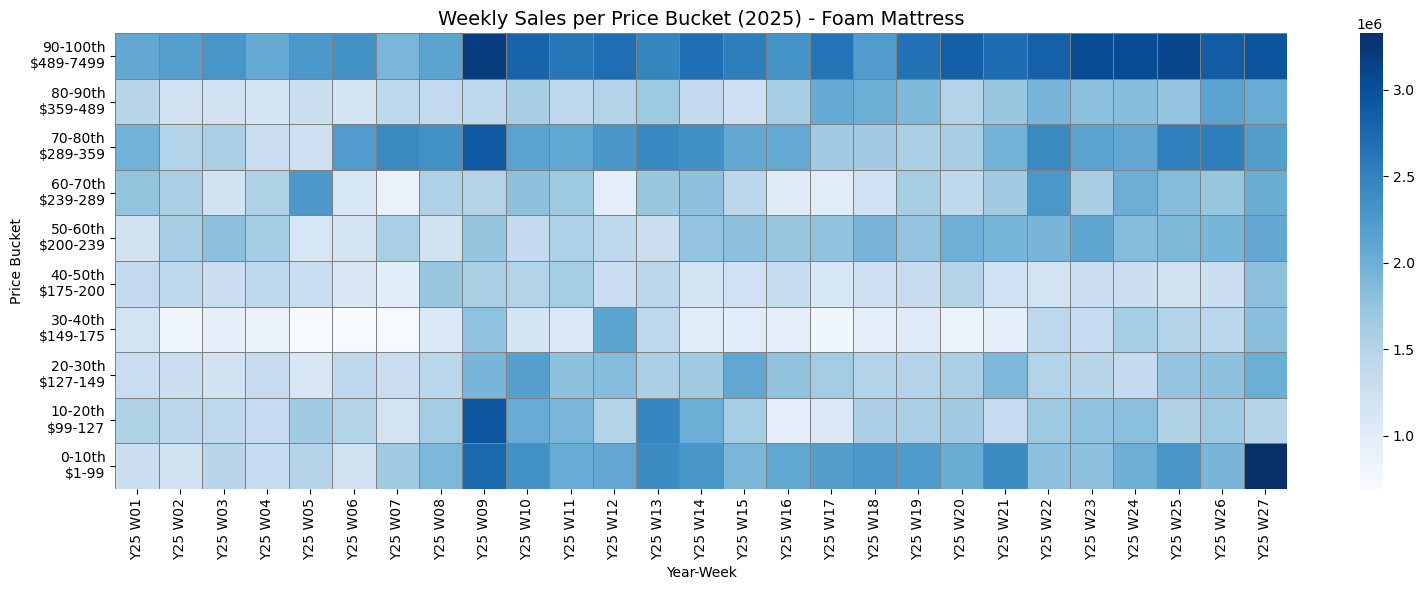

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2022904121.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']


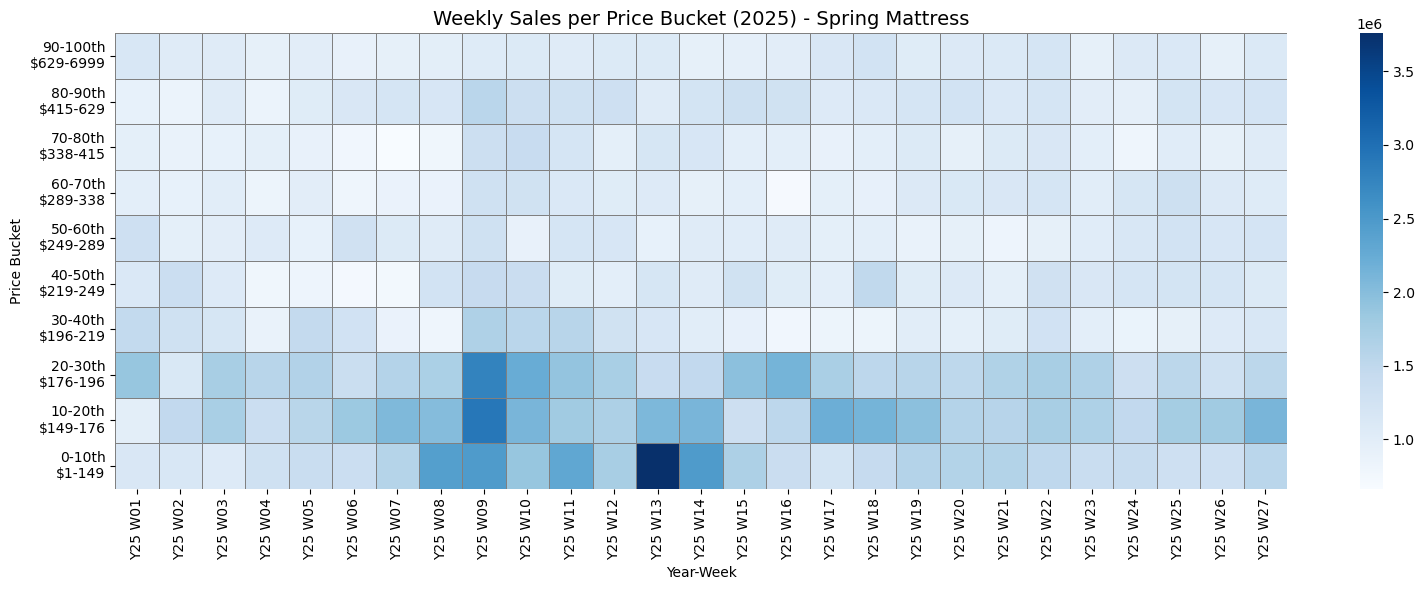

In [214]:

# 전처리: OTHERS 제외, 2025년만
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

category_list = ['Foam Mattress', 'Spring Mattress']

for cat in category_list:
    df_cat = df_filtered[df_filtered['category'] == cat].copy()
    # 가격 퍼센타일 구간 (해당 카테고리에서만)
    price_base = df_cat['RetailPrice'].dropna()
    if len(price_base) < 2:
        print(f"{cat} 데이터가 충분하지 않습니다.")
        continue

    percentiles = np.arange(0, 101, 10)
    price_bins = np.percentile(price_base, q=percentiles)
    # 동일 가격 구간이 있으면 에러 발생 → 중복 제거
    price_bins = np.unique(price_bins)
    # 라벨 재생성 (bin 길이에 맞게)
    bucket_labels = [
        f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 가격 버킷 할당
    df_cat['PriceBucket'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )
    df_cat['PriceBucket'] = pd.Categorical(
        df_cat['PriceBucket'],
        categories=bucket_labels[::-1],
        ordered=True
    )

    # 히트맵용 데이터
    heatmap_data = (
        df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']
              .sum()
              .unstack(fill_value=0)
    )

    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bucket (2025) - {cat}", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bucket")
    plt.tight_layout()
    plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\3999053721.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('PriceBucket')['RetailSales']


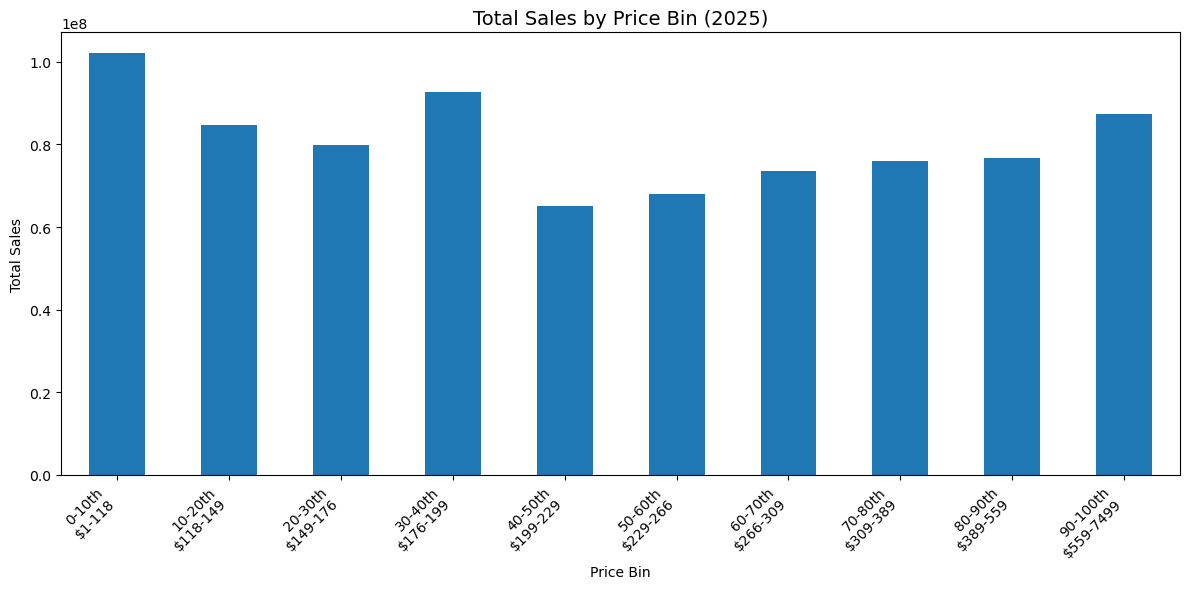

In [184]:
# PriceBucket 카테고리 오름차순으로 지정
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels,   # 오름차순
    ordered=True
)

# 오름차순 PriceBin 순서로 매출 집계
sales_by_bin = (
    df_filtered.groupby('PriceBucket')['RetailSales']
    .sum()
    .reindex(bucket_labels)     # 오름차순으로 정렬
)

# 막대그래프 시각화
plt.figure(figsize=(12, 6))
sales_by_bin.plot(kind='bar')

plt.title("Total Sales by Price Bin (2025)", fontsize=14)
plt.xlabel("Price Bin")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 가장 높은 price bucket에서 해당되는 데이터만 추출하기

In [233]:
# 1. 전처리: OTHERS 제외, 2025년만
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Foam Mattress만 추출
df_foam = df_filtered[df_filtered['category'] == 'Foam Mattress'].copy()

# 3. 퍼센타일 기반 price bin 계산
price_base = df_foam['RetailPrice'].dropna()
percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(price_base, q=percentiles)
price_bins = np.unique(price_bins)  # bin 경계 중복 제거

# 4. bin 라벨 생성
bucket_labels = [
    f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 5. price bucket 컬럼 생성
df_foam['PriceBucket'] = pd.cut(
    df_foam['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

print(df_foam.head())
df_foam.to_csv("df_foam_price_bucket_0721.csv", index=False)

      RetailerSku       category  subcategory  profile             size  \
13974  B0DP23FB8R  Foam Mattress  Cooling/Gel     10.0  California King   
13975  B0DP23FB8R  Foam Mattress  Cooling/Gel     10.0  California King   
13976  B0DP23FB8R  Foam Mattress  Cooling/Gel     10.0  California King   
13978  B0DP23FB8R  Foam Mattress  Cooling/Gel     10.0  California King   
13980  B0DSMH9CCM  Foam Mattress  Cooling/Gel     10.0             Full   

      bsr_ctgry_label Brand_raw Brand_adj  \
13974  01. Mattresses  NCHANMAR  NCHANMAR   
13975  01. Mattresses  NCHANMAR  NCHANMAR   
13976  01. Mattresses  NCHANMAR  NCHANMAR   
13978  01. Mattresses  NCHANMAR  NCHANMAR   
13980  01. Mattresses  PURRJOYS  PURRJOYS   

                                                   Title  WeekEnding  ...  \
13974  10 Inch California King Gel Memory Foam Mattre...  2025-05-03  ...   
13975  10 Inch California King Gel Memory Foam Mattre...  2025-02-08  ...   
13976  10 Inch California King Gel Memory Foam 

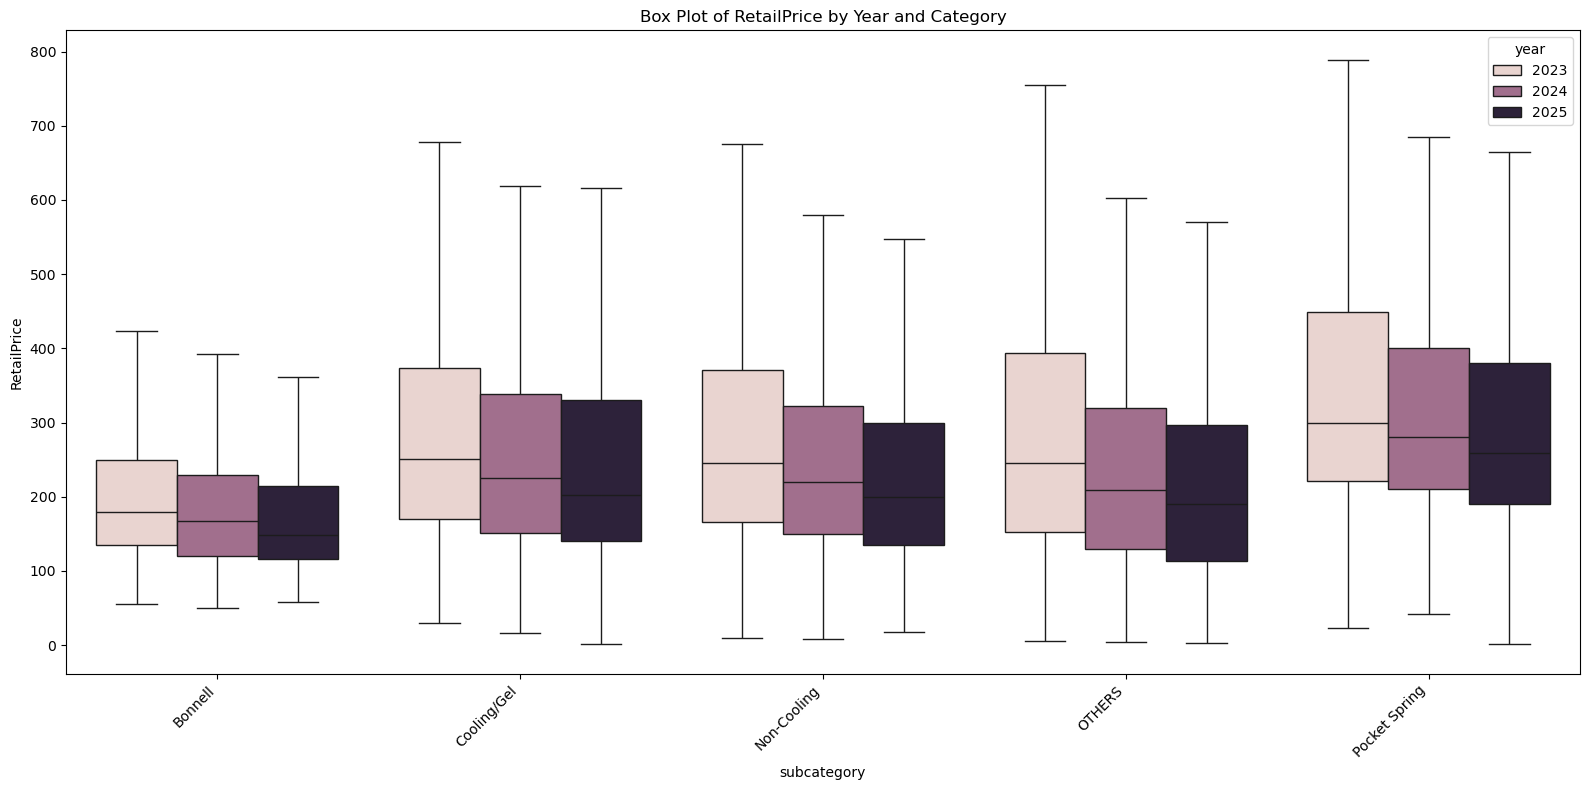

In [102]:

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df[df['RetailPrice'] > 0],  # 0 이하 제외 (로그변환 등에도 안전)
    x='subcategory',
    y='RetailPrice',
    hue='year',        # 분기로 색 구분
    showfliers=False         # 이상치 점 표시 안함 (원하면 True로)
)

plt.xticks(rotation=45, ha='right')
plt.title('Box Plot of RetailPrice by Year and Category')
plt.ylabel('RetailPrice')
plt.tight_layout()
plt.legend(title='year')
plt.show()

### Brand 별 매출 구하기

In [164]:
# 1. 2025년 데이터 필터링
df_2025 = df[df['year'] == 2025].copy()

# 2. Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 3. CSV로 저장
brand_sales_2025.to_csv('brand_sales_2025_sorted.csv', index=False)

# (선택) 상위 5개 출력
print(brand_sales_2025.head())

    Brand_raw   RetailSales
610     ZINUS  1.401663e+08
386   NOVILLA  6.276125e+07
168       FDW  3.963378e+07
352     MLILY  3.545190e+07
375    NECTAR  3.312092e+07


In [166]:
print(brand_sales_2025['Brand_raw'].nunique())

619
